<a href="https://www.kaggle.com/code/luizcavalcanti4/summit-davimoraes-luizfelipe-ipynb?scriptVersionId=350434767" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/davimoraes2012/summit-davimoraes-luizfelipe-ipynb?scriptVersionId=350679846" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Classificação de Ataque Cardíaco com SVM

**Objetivo:** classificar se o paciente teve ataque cardíaco (`1`) ou não (`0`) a partir dos exames.

**Dataset:** `Heart Attack.csv`, com 1.319 pacientes. As variáveis são idade, sexo, frequência cardíaca (`impluse`), pressão (`pressurehight` / `pressurelow`), glicose, CK-MB (`kcm`) e troponina. O alvo é `class`.

# Davi Moraes de Almeida - RGM: 11241100602
# Luiz Felipe Cavalcanti dos Santos - RGM: 11241101758

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

df = pd.read_csv('/kaggle/input/datasets/bharath011/heart-disease-classification-dataset/Heart Attack.csv')
df.head()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


## 1. Avaliação do banco de dados

In [2]:
print(df.shape)
df.info()
print('\nValores ausentes:\n', df.isna().sum())
print('\nDuplicados:', df.duplicated().sum())
print('\nClasses:\n', df['class'].value_counts())

(1319, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB

Valores ausentes:
 age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

Duplicados: 0

Classes:
 class
positive    810
negative    509
Name: count, dtype: int64


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1319.0,56.191812,13.647315,14.000,47.000,58.000,65.0000,103.0
gender,1319.0,0.659591,0.474027,0.000,0.000,1.000,1.0000,1.0
impluse,1319.0,78.336619,51.630270,20.000,64.000,74.000,85.0000,1111.0
pressurehight,1319.0,127.170584,26.122720,42.000,110.000,124.000,143.0000,223.0
pressurelow,1319.0,72.269143,14.033924,38.000,62.000,72.000,81.0000,154.0
glucose,1319.0,146.634344,74.923045,35.000,98.000,116.000,169.5000,541.0
kcm,1319.0,15.274306,46.327083,0.321,1.655,2.850,5.8050,300.0
troponin,1319.0,0.360942,1.154568,0.001,0.006,0.014,0.0855,10.3


### Distribuição das variáveis por diagnóstico

Cada gráfico compara os pacientes que **não tiveram** (azul) e os que **tiveram** (laranja) ataque cardíaco.
A caixa mostra onde está a maioria dos pacientes, a linha do meio é a mediana e os pontos soltos são os **outliers**.
Glicose, CK-MB e troponina estão em **escala logarítmica**, porque têm alguns valores muito altos que achatariam o gráfico.

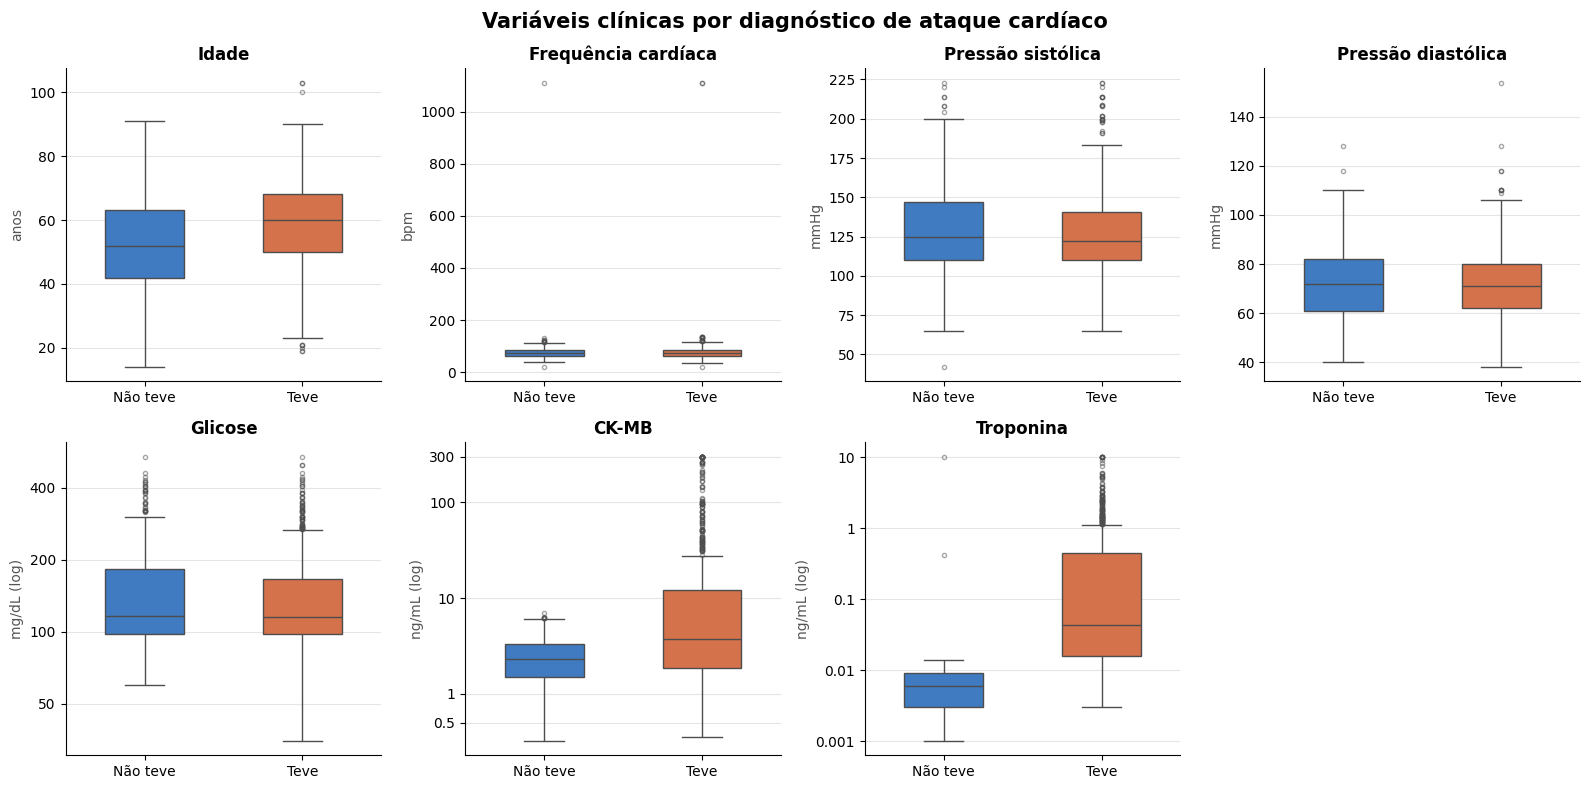

In [4]:
variaveis = {
    'age': ('Idade', 'anos', False),
    'impluse': ('Frequência cardíaca', 'bpm', False),
    'pressurehight': ('Pressão sistólica', 'mmHg', False),
    'pressurelow': ('Pressão diastólica', 'mmHg', False),
    'glucose': ('Glicose', 'mg/dL (log)', [50, 100, 200, 400]),
    'kcm': ('CK-MB', 'ng/mL (log)', [0.5, 1, 10, 100, 300]),
    'troponin': ('Troponina', 'ng/mL (log)', [0.001, 0.01, 0.1, 1, 10]),
}
cores = {'Não teve': '#2a78d6', 'Teve': '#eb6834'}
grafico = df.assign(Diagnóstico=df['class'].map({'negative': 'Não teve', 'positive': 'Teve'}))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (col, (titulo, unidade, log)) in zip(axes.flat, variaveis.items()):
    sns.boxplot(data=grafico, x='Diagnóstico', y=col, hue='Diagnóstico', palette=cores,
                order=['Não teve', 'Teve'], width=0.5, linewidth=1, legend=False,
                flierprops={'markersize': 3, 'alpha': 0.5}, ax=ax)
    if log:
        ax.set_yscale('log')
        ax.set_yticks(log)
        ax.set_yticklabels([str(v) for v in log])
        ax.minorticks_off()
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(unidade, color='#555555')
    ax.grid(axis='y', color='#e5e5e5')
    sns.despine(ax=ax)

axes.flat[-1].axis('off')
fig.suptitle('Variáveis clínicas por diagnóstico de ataque cardíaco', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

- Não há `NaN` nem duplicados. As classes estão um pouco desbalanceadas (61% positivo), por isso a divisão será estratificada.
- `class` é a única coluna de texto e precisa de encoding.
- Existem valores impossíveis, como `impluse` = 1111 bpm, que precisam ser tratados.
- `glucose`, `kcm` e `troponin` são muito assimétricas, então vamos aplicar log antes do SVM.

## 2. Tratativa de dados ausentes

Os valores impossíveis viram `NaN`:
- `impluse` fora do intervalo de 30 a 250 bpm
- `pressurelow` ≥ `pressurehight`

Depois esses `NaN` são preenchidos com a **mediana** dentro do pipeline, calculada só com os dados de treino.

In [5]:
df_clean = df.copy()
df_clean.loc[(df_clean['impluse'] > 250) | (df_clean['impluse'] < 30), 'impluse'] = np.nan
df_clean.loc[df_clean['pressurelow'] >= df_clean['pressurehight'], ['pressurehight', 'pressurelow']] = np.nan

df_clean.isna().sum()

age               0
gender            0
impluse           5
pressurehight    11
pressurelow      11
glucose           0
kcm               0
troponin          0
class             0
dtype: int64

## 3. Tratativa de encoding

- `class` (texto) → `LabelEncoder`: negative = 0, positive = 1
- `gender` já está em 0/1, então não precisa de encoding.

In [6]:
le = LabelEncoder()
df_clean['target'] = le.fit_transform(df_clean['class'])
df_clean = df_clean.drop(columns='class')

assert df_clean.select_dtypes(exclude='number').empty
df_clean.dtypes

age                int64
gender             int64
impluse          float64
pressurehight    float64
pressurelow      float64
glucose          float64
kcm              float64
troponin         float64
target             int64
dtype: object

## 4. Divisão dos dados em treino e teste

- **X**: as 8 variáveis clínicas (entradas do modelo)
- **y**: o diagnóstico `target` (0 = não teve, 1 = teve ataque cardíaco)

Separamos **80% para treino** e **20% para teste**. O `stratify=y` mantém a mesma proporção de positivos e negativos nos dois conjuntos, e o `random_state=42` garante que a divisão seja sempre a mesma.

In [7]:
X = df_clean.drop(columns='target')
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Treino: {X_train.shape[0]} pacientes')
print(f'Teste:  {X_test.shape[0]} pacientes')
pd.DataFrame({
    'Treino (%)': y_train.value_counts(normalize=True).mul(100).round(1),
    'Teste (%)': y_test.value_counts(normalize=True).mul(100).round(1),
}).rename(index={0: '0 - não teve', 1: '1 - teve'})

Treino: 1055 pacientes
Teste:  264 pacientes


,Treino (%),Teste (%)
target,,
1 - teve,61.4,61.4
0 - não teve,38.6,38.6


## 5. Pré-processamento

O SVM trabalha com distâncias, então as variáveis precisam estar na mesma escala.

| Variáveis | Etapas |
|---|---|
| `glucose`, `kcm`, `troponin` | mediana nos ausentes → log → padronização |
| `age`, `impluse`, `pressurehight`, `pressurelow` | mediana nos ausentes → padronização |
| `gender` | sem alteração (já é 0/1) |

Tudo fica dentro de um `Pipeline`. Assim, a mediana e a padronização são calculadas **só com os dados de treino**.

In [8]:
prep = ColumnTransformer([
    ('log', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('log', FunctionTransformer(np.log1p)),
                      ('sc', StandardScaler())]), ['glucose', 'kcm', 'troponin']),
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), ['age', 'impluse', 'pressurehight', 'pressurelow']),
    ('bin', 'passthrough', ['gender']),
])

pipe = Pipeline([('prep', prep), ('svm', SVC())])
pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('log',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['glucose', 'kcm',
                                                   'troponin']),
                                                 ('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['age', 'impluse',
                                                   'pressurehight',
                                                   'pressurelow']),
                                                 ('bin', 'passthrough',
                                                  ['gender'])])),
                ('svm', SVC())])

## 6. Aplicação do GridSearchCV

O `GridSearchCV` testa todas as combinações de hiperparâmetros do SVM e escolhe a melhor, usando **validação cruzada de 5 partes** só nos dados de treino.

| Hiperparâmetro | O que controla | Valores testados |
|---|---|---|
| `kernel` | formato da fronteira de decisão | `linear`, `rbf` |
| `C` | quanto o modelo pune os erros no treino | 0.1, 1, 10, 100 |
| `gamma` | alcance de cada ponto (só no `rbf`) | `scale`, 0.01, 0.1 |

A métrica usada para escolher o melhor modelo é o **F1-score**, que equilibra precisão e recall.

In [9]:
params = [
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10, 100]},
    {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 0.01, 0.1]},
]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipe, params, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print('Combinações testadas:', len(grid.cv_results_['params']))
print('Melhores parâmetros:', grid.best_params_)
print(f'Melhor F1 na validação cruzada: {grid.best_score_:.4f}')

Combinações testadas: 16
Melhores parâmetros: {'svm__C': 100, 'svm__kernel': 'linear'}
Melhor F1 na validação cruzada: 0.8990


In [10]:
resultados = pd.DataFrame(grid.cv_results_)
resultados = resultados[['param_svm__kernel', 'param_svm__C', 'param_svm__gamma', 'mean_test_score', 'rank_test_score']]
resultados.columns = ['kernel', 'C', 'gamma', 'F1 médio', 'ranking']
resultados.sort_values('ranking').head(10).round(4)

,kernel,C,gamma,F1 médio,ranking
3,linear,100.0,NaN,0.8990,1
2,linear,10.0,NaN,0.8923,2
15,rbf,100.0,0.1,0.8800,3
13,rbf,100.0,scale,0.8775,4
14,rbf,100.0,0.01,0.8737,5
12,rbf,10.0,0.1,0.8657,6
10,rbf,10.0,scale,0.8601,7
1,linear,1.0,NaN,0.8552,8
7,rbf,1.0,scale,0.8452,9
9,rbf,1.0,0.1,0.8437,10


## 7. Treino do modelo e teste

O `GridSearchCV` já treina o melhor modelo com **todos os dados de treino** (`best_estimator_`). Agora ele é testado com os **20% de teste**, que ele nunca viu.

Também comparamos a acurácia no treino com a do teste: se o treino for muito maior, o modelo decorou os dados (**overfitting**).

In [11]:
modelo = grid.best_estimator_

pred_treino = modelo.predict(X_train)
y_pred = modelo.predict(X_test)

print(f'Acurácia no treino: {accuracy_score(y_train, pred_treino):.4f}')
print(f'Acurácia no teste:  {accuracy_score(y_test, y_pred):.4f}')

Acurácia no treino: 0.8872
Acurácia no teste:  0.9015


              precision    recall  f1-score   support

0 - não teve       0.85      0.91      0.88       102
    1 - teve       0.94      0.90      0.92       162

    accuracy                           0.90       264
   macro avg       0.89      0.90      0.90       264
weighted avg       0.90      0.90      0.90       264



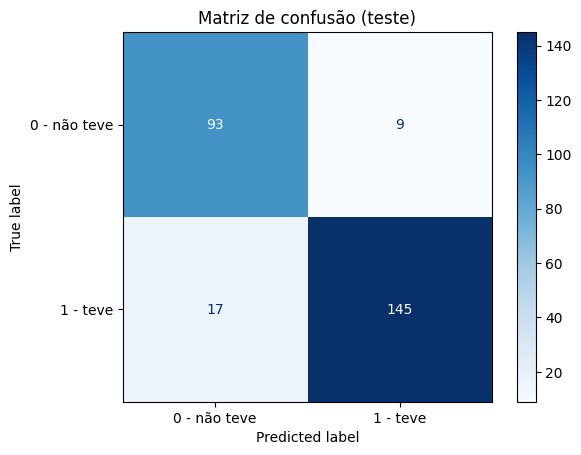

In [12]:
print(classification_report(y_test, y_pred, target_names=['0 - não teve', '1 - teve']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['0 - não teve', '1 - teve'], cmap='Blues')
plt.title('Matriz de confusão (teste)')
plt.show()

Como ler a matriz de confusão:
- **Diagonal principal:** pacientes classificados corretamente.
- **Canto inferior esquerdo:** pacientes que tiveram ataque cardíaco, mas o modelo disse que não (**falso negativo**). É o erro mais grave nesse problema.
- **Canto superior direito:** pacientes que não tiveram, mas o modelo disse que sim (**falso positivo**).

## 8. Classificação do dataset

Cada paciente é classificado por um modelo que **não o viu no treino** (`cross_val_predict`).

In [13]:
df_classificado = df_clean.copy()
df_classificado['predicao'] = cross_val_predict(modelo, X, y, cv=cv)

print(f'Acurácia na base inteira: {accuracy_score(y, df_classificado["predicao"]):.4f}')
print(df_classificado['predicao'].value_counts().rename({0: 'negativo (0)', 1: 'positivo (1)'}))

df_classificado.fillna(df_clean.median()).to_csv('heart_attack_classificado.csv', index=False)
df_classificado.head()

Acurácia na base inteira: 0.8961
predicao
positivo (1)    747
negativo (0)    572
Name: count, dtype: int64


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,target,predicao
0,64,1,66.0,160.0,83.0,160.0,1.80,0.012,0,0
1,21,1,94.0,98.0,46.0,296.0,6.75,1.060,1,1
2,55,1,64.0,160.0,77.0,270.0,1.99,0.003,0,0
3,64,1,70.0,120.0,55.0,270.0,13.87,0.122,1,1
4,55,1,64.0,112.0,65.0,300.0,1.08,0.003,0,0


## 9. Conclusão

- **Avaliação:** a base não tinha `NaN` explícitos, mas tinha valores impossíveis de frequência cardíaca e de pressão.
- **Dados ausentes:** esses valores viraram `NaN` e foram imputados pela mediana.
- **Encoding:** `class` virou 0/1, e o dataset final é todo numérico.
- **Divisão:** 80% treino / 20% teste, estratificada.
- **GridSearchCV:** testou kernels linear e rbf com vários valores de `C` e `gamma`; o melhor foi o **kernel linear**.
- **Treino e teste:** cerca de **90% de acurácia** no teste, próxima da acurácia no treino (sem overfitting). A classificação do dataset inteiro deu resultado parecido. As variáveis que mais pesam são a troponina e o CK-MB (`kcm`).